Fintech Analytics Project

# Finance Analytics: Exploratory Data Analysis (EDA)

## End-to-End Data Analytics Project

**Tools Used**
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- PostgreSQL
- Power BI
- Excel (Power Query)

### Dataset

- Customers: 5,000
- Transactions: 50,000

### Python Exploratory Data Analysis (EDA) & Visualization

This notebook conducts a comprehensive Exploratory Data Analysis (EDA) on a fintech dataset comprising customer demographics and financial transactions. The goal is to extract actionable business insights regarding revenue performance, customer segmentation, fraud patterns, and risk exposure.

# Import Libraries

Import the required Python libraries for data analysis and visualization.

In [ ]:
# Fintech Analytics Project
# Python Exploratory Data Analysis

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display Options
# Shows all columns when displaying DataFrames
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# Ignore Warnings
# Removes unnecessary warning messages Makes notebook cleaner.
import warnings
warnings.filterwarnings('ignore')

pd.options.display.float_format = '{:,.2f}'.format


## 1. Data Ingestion & Initial Structural Inspection

Before performing deep analysis, we ingest our primary data tables (`customers` and `transactions`) and perform baseline validation structural checks (`.shape`, `.columns`, `.info()`, and `.describe()`) to verify row counts, identify data types, and spot immediate anomalies.

# Load Dataset

Load the customer and transaction datasets into Pandas DataFrames.

In [ ]:
customers = pd.read_csv(r'E:\All My Study\Data Analytics Projects\All My Projects Inside\01 data\Project_3_Finance_Analysis\customers_clean_csv.csv')

transactions = pd.read_csv(r'E:\All My Study\Data Analytics Projects\All My Projects Inside\01 data\Project_3_Finance_Analysis\finance_transactions_clean_csv.csv')

# Data Inspection

Understand the structure of the datasets by examining rows, columns, data types, and summary statistics.

# Initial Inspection
# What does head() do?
# Returns first 5 rows.
# Used to quickly inspect data structure.

In [ ]:
customers.head()

In [ ]:
transactions.head()

In [ ]:
customers.shape

In [ ]:
transactions.shape

In [ ]:
customers.columns

In [ ]:
transactions.columns

In [ ]:
customers.info()

In [ ]:
transactions.info()

In [ ]:
customers.describe()

In [ ]:
transactions.describe()

## 2. Data Quality & Business Validation Checks

To guarantee the reliability of our downstream reporting, we profile our datasets for:
* **Missing values** (`.isnull().sum()`)
* **Duplicate rows** (`.duplicated().sum()`)
* **Entity Cardinality** (Unique customer and transaction identifiers)
* **Financial Controls Reconciliation** (Summing gross metrics to verify data completeness)

In [ ]:
# Missing Values

customers.isnull().sum()

In [ ]:
# Missing Values

transactions.isnull().sum()

In [ ]:
# Duplicate Records

customers.duplicated().sum()

In [ ]:
# Duplicate Records

transactions.duplicated().sum()

In [ ]:
# Unique Customers

customers['customer_id'].nunique()

In [ ]:
# Unique Transactions

transactions['transaction_id'].nunique()

In [ ]:
# Total Amount

transactions['amount'].sum()

In [ ]:
# Total Fees

transactions['fee_amount'].sum()

In [ ]:
# Total Tax

transactions['tax_amount'].sum()

In [ ]:
# Exploratory Data Analysis (EDA)
# First created a working copy:

df = transactions.copy()

## 3. Transactional Distribution & Operational Performance

We begin our behavioral analysis by examining operational metrics, starting with the distribution of transaction processing states (`Approved`, `Failed`, `Pending`, `Cancelled`) to check transaction success rates.

In [ ]:
# Transaction Status Distribution

df['transaction_status'].value_counts()

In [ ]:
# Visualization
# Why use countplot?
# Countplot shows: Frequency, Category Counts, Distribution
# Useful for: Approved, Failed, Pending, Cancelled

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='transaction_status'
)

plt.title('Transaction Status Distribution')

plt.show()

In [ ]:
# Revenue Overview
# Difference between Mean and Median?
# Mean (Average): The sum of all values divided by the total number of values. It is the "balance point" of the data.
# Median (Middle Value): The exact middle number when the data is sorted from smallest to largest. It splits the data 
# perfectly in half (50% of values are below it, 50% are above).

total_revenue = df['amount'].sum()
average_transaction = df['amount'].mean()
maximum_transaction = df['amount'].max()
minimum_transaction = df['amount'].min()
median_transaction = df['amount'].median()

print(f"Total Revenue: ₹{total_revenue:,.2f}")
print(f"Average Transaction Value: ₹{average_transaction:,.2f}")
print(f"Maximum Transaction Value: ₹{maximum_transaction:,.2f}")
print(f"Minimum Transaction Value: ₹{minimum_transaction:,.2f}")
print(f"Median Transaction Value: ₹{median_transaction:,.2f}")

## 4. Gross Revenue Distribution Analysis

A key priority is understanding the variance, baseline concentration, and symmetry of our financial portfolio values. 

### Analytical Cheat Sheet:
* **Mean (Average)**: Highly sensitive to extreme values. A few massive values will pull the mean artificially high.
* **Median (Middle Point)**: Robust against outliers. It represents the value of a truly "typical" platform user.
* **Skewness (Direction of Tail)**: Our data is heavily **Right-Skewed (Positively Skewed)** because a long tail stretches toward unique, high-value transactions, meaning small-value transactions heavily dominate the platform daily.

In [ ]:
# REVENUE DISTRIBUTION ANALYSIS
# Visual Tool: Histogram (Histplot)
# Purpose: Shows the frequency distribution of transaction amounts.

plt.figure(figsize=(10,6))

sns.histplot(
    df['amount'],
    bins=50,
    kde=True,
    color='skyblue',                                # This changes the color of the bars
    line_kws={'color': 'red', 'linewidth': 2}       # This changes the KDE line to red and makes it thicker
)

plt.title('Transaction Amount Distribution')
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')

plt.show()

## 5. Temporal Revenue Trends

By converting plain-text timestamps into structured `datetime` format, we aggregate transaction values chronologically to map long-term revenue trajectories, look for month-over-month growth, and identify potential seasonality.

In [ ]:
# Monthly Revenue Trend
# Is revenue growing over time?
# Convert Date Column
# Without datetime conversion: 2025-05-01 is treated as text.
# After conversion: datetime object which enables time analysis.

df['transaction_date'] = pd.to_datetime(df['transaction_date'], dayfirst=True)

In [ ]:
# Create Month Column

df['month'] = df['transaction_date'].dt.to_period('M')

In [ ]:
# Monthly Revenue

monthly_revenue = (
    df.groupby('month')['amount']
      .sum()
      .reset_index()
)

monthly_revenue.head()

In [ ]:
# Visualization
# Why use a Line Chart?
# Time Series Data, Trends, Growth Patterns, Seasonality
# What To Look For?
# Growth periods, Declines, Revenue spikes, Seasonality

plt.figure(figsize=(12,6))

plt.plot(
    monthly_revenue['month'].astype(str),
    monthly_revenue['amount'],
    marker='o'
)

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 6. Revenue Drivers: Transaction Types & Channels

To isolate our primary value drivers, we break down revenue metrics across two core operational dimensions:
1. **Transaction Type**: What actions are users taking? (e.g., Transfers, Payments)
2. **Channel Choice**: Which touchpoints handle the largest shares of economic velocity? (e.g., Mobile, Web)

In [ ]:
# Revenue by Transaction Type

revenue_by_type = (
    df.groupby('transaction_type')['amount']
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

revenue_by_type.style.format({'amount': '{:,.2f}'})

In [ ]:
# Visualization
# Why Horizontal Bar Chart?
# Transfer transactions contribute the largest share of revenue, 
# suggesting customers primarily use the platform for money movement activities.

plt.figure(figsize=(10,6))

# The Clean DataFrame Method:
sns.barplot(
    data=revenue_by_type,        # Pass the whole table here
    x='amount',                  # Target the 'amount' column for the horizontal bars
    y='transaction_type',        # Target the 'transaction_type' column for the vertical labels
    palette='Blues_r'            # Optional: Adds a beautiful dark-to-light blue gradient
)

plt.title('Revenue by Transaction Type')
plt.xlabel('Revenue')
plt.ylabel('Transaction Type')

plt.show()

In [ ]:
# Revenue by Payment Method
# Which payment channel drives the most business?

revenue_by_channel = (
    df.groupby('channel')['amount']
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

revenue_by_channel

In [ ]:
# DATA AGGREGATION (.agg creates columns explicitly named 'sum' and 'count')

revenue_by_channel = (
    df.groupby('channel')['amount']
      .agg(['sum', 'count'])
      .sort_values(by='sum', ascending=False) # Must sort by 'sum' now
      .reset_index()
)

revenue_by_channel

In [ ]:
# Visualization (Using string column names)

plt.figure(figsize=(10,6))

sns.barplot(
    data=revenue_by_channel,       
    x='sum',                       # <-- Changed from 'amount' to 'sum'
    y='channel',                   
    palette='Blues_r'              
)

plt.title('Revenue by Channel')
plt.xlabel('Total Revenue')
plt.ylabel('Channel')

plt.show()

## 7. Customer Demographics & Segment Deep-Dive

To shift from general transactional volume to user-centric business intelligence, we engineer a customer `age` column using date-of-birth attributes and perform an internal **left-merge** to unify demographic markers with transactional data.

In [ ]:
# Revenue by Customer Segment


# Customer Age Analysis
# Convert Date of Birth
customers['date_of_birth'] = pd.to_datetime(customers['date_of_birth'], dayfirst=True)

# Create Age Column
customers['age'] = (pd.Timestamp.today().year - customers['date_of_birth'].dt.year)

# Merge Customer and Transaction Data
# Merge transactions with customer information
merged_df = pd.merge(
    df,
    customers,
    on='customer_id',
    how='left'
)

merged_df.head()

In [ ]:
# Revenue by Customer Segment

customers.columns.tolist()

In [ ]:
# Revenue by Segment

revenue_by_segment = (
    merged_df.groupby('customer_segment')['amount']
             .sum()
             .sort_values(ascending=False)
)

revenue_by_segment

In [ ]:
# Visualization
# Premium customers generate the highest revenue contribution, 
# indicating that retention strategies for this segment should be prioritized.

plt.figure(figsize=(10,6))

sns.barplot(
    x=revenue_by_segment.values,
    y=revenue_by_segment.index
)

plt.title('Revenue by Customer Segment')
plt.xlabel('Revenue')
plt.ylabel('Customer Segment')

plt.show()

## 8. High-Value Customer Concentrations (Pareto Analysis)

Applying the **Pareto Principle (80/20 Rule)**, we analyze our top 10 revenue-generating individuals. Identifying these critical accounts allows us to prioritize high-value retention frameworks, bespoke customer support models, and exclusive premium product development tracks.

In [ ]:
# Top 10 Customers
# Top Revenue Customers

top_customers = (
    merged_df.groupby(['customer_id', 'customer_name'])['amount']
             .sum()
             .reset_index()
             .sort_values('amount',ascending=False)
             .head(10)
)

top_customers

In [ ]:
# Visualization
# Why Analyze Top Customers?

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_customers,
    x='amount',
    y='customer_name'
)

plt.title('Top 10 Revenue Generating Customers')
plt.xlabel('Revenue')
plt.ylabel('Customer')

plt.show()

## 9. Structural Cost Analysis: Secondary Revenue & Regulatory Drag

We construct a multi-variable metric profile to benchmark cross-platform performance indicators against our operational parameters. This directly isolates:
* **Primary Volume Velocity**: Core revenue generated by user transactions.
* **Secondary Revenue Streams**: Stability vectors contributed by platform usage fees.
* **Regulatory Cost Drag**: Outbound financial requirements represented by aggregate taxes.

In [ ]:
# Revenue vs Fees

total_fee = df['fee_amount'].sum()

print(f"Total Fee Revenue: ₹{total_fee:,.2f}")

In [ ]:
# Monthly Fee Trend

monthly_fee = (
    df.groupby('month')['fee_amount']
      .sum()
      .reset_index()
)

monthly_fee.head()

In [ ]:
# Visualization
# Fee income remains relatively stable and represents a secondary revenue stream beyond transaction volume.

plt.figure(figsize=(12,6))

plt.plot(
    monthly_fee['month'].astype(str),
    monthly_fee['fee_amount'],
    marker='o'
)

plt.title('Monthly Fee Revenue')
plt.xlabel('Month')
plt.ylabel('Fee Revenue')

plt.xticks(rotation=45)

plt.show()

In [ ]:
# Revenue vs Tax

total_tax = df['tax_amount'].sum()

print(f"Total Tax Amount: ₹{total_tax:,.2f}")

In [ ]:
# Revenue, Fees and Tax Comparison

comparison = pd.DataFrame({
    'Metric': ['Revenue', 'Fees', 'Tax'],
    'Amount': [
                df['amount'].sum(),
                df['fee_amount'].sum(),
                df['tax_amount'].sum()
              ]
})
    
comparison

In [ ]:
# Visualization
# Why Compare Revenue, Fees and Tax?
# Helps understand: Profitability drivers, Cost structure, Operational efficiency, Regulatory burden

plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison,
    x='Metric',
    y='Amount'
)

plt.title('Revenue vs Fees vs Tax')

plt.show()

In [ ]:
# Revenue Correlation Analysis
# Which numerical variables move together?

numeric_cols = [
                'amount',
                'fee_amount',
                'tax_amount',
                'risk_score'
               ]

corr_matrix = df[numeric_cols].corr()

corr_matrix


In [ ]:
# Heatmap
# Plotting the correlation matrix as a Heatmap
# What Does Correlation Measure?
# Strength and direction of relationship between variables.

plt.figure(figsize=(8, 6))

sns.heatmap(
    data=corr_matrix, 
    annot=True,             # True = Prints the actual correlation numbers inside the squares
    cmap='coolwarm',        # A beautiful blue-to-red color palette (Red=Positive, Blue=Negative)
    fmt='.2f',              # Forces numbers to show exactly 2 decimal places
    vmin=-1, vmax=1         # Sets the color bounds to match the statistical correlation scale
)

plt.title('Financial Metrics Correlation Matrix')
plt.show()

## 10. Platform Demographic Distribution Analysis

To refine our marketing personalization and product market fit strategies, we dissect our user base split across core categorical fields:
* **Customer Segment Base**: Market penetration across tier definitions.
* **Gender Demographics**: Platform demographic alignment.
* **Age Distribution**: Generational cohort targeting and digital tool adoption.

In [ ]:
# Customer Segment Distribution
# What type of customers use the platform?

segment_count = customers['customer_segment'].value_counts()

segment_count


In [ ]:
# Percentage Distribution
# normalize=True (Returns proportions instead of counts)

segment_percentage = (customers['customer_segment'].value_counts(normalize=True) * 100)

segment_percentage

In [ ]:
# Visualization
# Standard customers represent the largest customer base, indicating strong mass-market adoption.

plt.figure(figsize=(8,5))

sns.countplot(
    data=customers,
    x='customer_segment'
)

plt.title('Customer Segment Distribution')

plt.show()

In [ ]:
# Gender Analysis
# What is the gender distribution of customers?

gender_count = customers['gender'].value_counts()

gender_count


In [ ]:
# Percentage Distribution

gender_percentage=(customers['gender'].value_counts(normalize=True) * 100)

gender_percentage

In [ ]:
# Visualization
# Why Analyze Gender?
# Marketing Campaigns, Customer Personalization, Product Development, Customer Experience

plt.figure(figsize=(6,5))

sns.countplot(
    data=customers,
    x='gender'
)

plt.title('Gender Distribution')

plt.show()

In [ ]:
# Check Age Statistics

customers['age'].describe()

In [ ]:
# Visualization
# Why Age Analysis?
# Age often impacts: Spending Habits, Digital Adoption, Risk Profile, Financial Products

plt.figure(figsize=(10,6))

sns.histplot(
    customers['age'],
    bins=20,
    kde=True
)

plt.title('Customer Age Distribution')

plt.show()

In [ ]:
# Revenue by Age
# Now combine demographics with transactions.
# Revenue by Age

age_revenue = (
    merged_df.groupby('age')['amount']
             .sum()
             .reset_index()
)

age_revenue.head()

In [ ]:
# Visualization
# Customers aged 30–45 generate the highest revenue, 
# suggesting this demographic represents the platform's most valuable user group.

plt.figure(figsize=(12,6))

plt.plot(
    age_revenue['age'],
    age_revenue['amount']
)

plt.title('Revenue by Age')
plt.xlabel('Age')
plt.ylabel('Revenue')

plt.show()

In [ ]:
# Annual Income Analysis
# Summary Statistics

customers['annual_income'].describe()

In [ ]:
# Visualization
# Why Analyze Income?
# Income influences: Spending Capacity, Transaction Frequency, Credit Eligibility, Investment Products

plt.figure(figsize=(10,6))

sns.histplot(
    customers['annual_income'],
    bins=30,
    kde=True
)

plt.title('Annual Income Distribution')

plt.show()

In [ ]:
# Revenue by Customer Segment

revenue_segment = (
    merged_df.groupby('customer_segment')['amount']
             .sum()
             .sort_values(ascending=False)
)

revenue_segment

In [ ]:
# Visualization
# Which professions generate the most revenue?

plt.figure(figsize=(8,5))

sns.barplot(
    x=revenue_segment.values,
    y=revenue_segment.index
)

plt.title('Revenue by Customer Segment')

plt.show()

In [ ]:
# Revenue by Occupation
# Top 5 Occupations

occupation_revenue = (
    merged_df.groupby('occupation')['amount']
             .sum()
             .sort_values(ascending=False)
)

occupation_revenue


In [ ]:
# Visualization
# Salaried professionals contribute the highest transaction volume, indicating strong 
# engagement among employed customers.


plt.figure(figsize=(12,6))

sns.barplot(
    x=occupation_revenue.values,
    y=occupation_revenue.index
)

plt.title('Top Revenue Generating Occupations')

plt.show()

In [ ]:
# Revenue by State

state_revenue = (
    merged_df.groupby('state')['amount']
             .sum()
             .sort_values(ascending=False)
)

state_revenue.head(10)

In [ ]:
# Visualization
# The top-performing states contribute a significant portion of total transaction value, 
# indicating geographic revenue concentration.

plt.figure(figsize=(12,6))

sns.barplot(
    x=state_revenue.head(10).values,
    y=state_revenue.head(10).index
)

plt.title('Top 10 States by Revenue')

plt.show()

## 11. User Acquisition Velocities & Scale Patterns

By indexing historical onboarding timelines, we group user activation dates into a localized timeframe matrix. This permits accurate tracking of multi-year business scale trends and validates downstream marketing efficacy.

In [ ]:
# Customer Acquisition Trend
# Are we acquiring customers consistently?
# Convert Join Date

customers['join_date'] = pd.to_datetime(customers['join_date'], dayfirst=True)

In [ ]:
# Create Month

customers['join_month'] = customers['join_date'].dt.to_period('M')

In [ ]:
# Monthly Acquisitions

customer_growth = (
    customers.groupby('join_month')
             .size()                                    # Pandas counts how many rows (customers) exist for each month
             .reset_index(name='customers_added')       # doing two things at the same time: flatten the Series into a clean, 2-column DataFrame.
                                                        # We explicitly tell Pandas: "Take that unnamed list of counts and name the new column 'customers_added'."
)

customer_growth.head()



In [ ]:
customer_growth['Year'] = (
    customer_growth['join_month']
    .astype(str)                            # 1. Turn the dates into plain text strings
    .str[:4]                                # 2. Slice and grab only the first 4 characters
)

yearly_growth = (
    customer_growth.groupby('Year')          # 1. Group the months by their Year ("2022", "2023"...)
                   ['customers_added']       # 2. Look at the monthly customer numbers
                   .sum()                    # 3. Add all 12 months together for that year
                   .reset_index()            # 4. Turn the result back into a clean table
)

yearly_growth


In [ ]:
# Visualization
# Why Track Customer Acquisition?
# It helps measure: Business Growth, Marketing Effectiveness, User Adoption, Market Expansion

plt.figure(figsize=(14,6))

plt.plot(
    customer_growth['join_month'].astype(str),
    customer_growth['customers_added'],
    marker='o'
)

plt.title('Customer Acquisition Trend')
plt.xlabel('Month')
plt.ylabel('Customers Added')

plt.xticks(
    ticks=range(0,len(customer_growth),3),
    labels=customer_growth['join_month'].astype(str)[::3],
    rotation=45
)

plt.tight_layout()

plt.show()

In [ ]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=yearly_growth,
    x='Year',
    y='customers_added'
)

plt.title('Yearly Customer Acquisition')
plt.xlabel('Year')
plt.ylabel('Customers Added')

plt.show()

## 12. Risk Intelligence: Fraud Incident Profiling

We switch focus to platform security and loss prevention. By analyzing our baseline fraud rate and comparing transaction profiles between legitimate traffic and malicious activity, we can map financial exposure vectors.

In [ ]:
# Fraud Analysis
# Fraud Overview
# Total Fraud Transactions

# Create a filter where 'Yes' becomes True (1) and 'No' becomes False (0)

is_fraud_numeric = (df['is_fraud'] == 'Yes')
fraud_count = is_fraud_numeric.sum()

print(f"Fraud Transactions: {fraud_count:,}")                   # Added a comma format for large counts

In [ ]:
# Fraud Percentage
# Fraud Rate (.mean() calculates the exact percentage of Trues)
# Why use Mean()?
# Because: is_fraud, 0 = Not Fraud, 1 = Fraud

fraud_rate = is_fraud_numeric.mean() * 100

print(f"Fraud Rate: {fraud_rate:.2f}%")

In [ ]:
# Fraud vs Non-Fraud Distribution

df['is_fraud'].value_counts().reset_index()

In [ ]:
# Visualization
# Fraudulent transactions account for only a small percentage of overall activity, but their financial impact may be significant.

plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x='is_fraud',
    palette=["#1bd857", "#e90e0e"],         # Now it maps perfectly: No=Green, Yes=Red
)

plt.title('Fraud vs Non-Fraud Transactions')
plt.xlabel('Is Fraud')
plt.ylabel('Transaction Count')

plt.show()

In [ ]:
# 1. Run the mapping and check the first few rows to verify it works
df['is_fraud'].replace({'No': 'Legitimate', 'Yes': 'Fraud'}).head()

In [ ]:
# 2. Assign the working transformation to a brand-new descriptive column
df['fraud_status'] = df['is_fraud'].replace({'No': 'Legitimate', 'Yes': 'Fraud'})

In [ ]:
# 3. Use your newly created column for a quick analysis
df.groupby('fraud_status')['amount'].mean()

In [ ]:
# Visualization
# Fraudulent transactions account for only a small percentage of overall activity, but their financial impact may be significant.

plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x='fraud_status',                                 # Use your new descriptive column string
    palette=["#1bd857", "#e90e0e"]                # Optional: Clean blue for legitimate, red for fraud!
)

plt.title('Distribution of Fraud vs Legitimate Transactions')
plt.xlabel('Transaction Status')
plt.ylabel('Number of Transactions')

plt.show()

In [146]:
# Fraud Amount Analysis
# How much money is involved in fraud?
# Total Fraud Amount

fraud_amount = (df[df['is_fraud'] == 'Yes']['amount'].sum())

print(f"Fraud Amount: ₹{fraud_amount:,.2f}")

Fraud Amount: ₹5,969,443.52


In [147]:
# Average Fraud Transaction

avg_fraud_amount = (df[df['is_fraud'] == 'Yes']['amount'].mean())

print(f"Average Fraud Amount: ₹{avg_fraud_amount:,.2f}")

Average Fraud Amount: ₹9,475.31


In [148]:
# Compare Fraud vs Non-Fraud
# Why Compare Fraud and Non-Fraud Amounts?
# Helps identify: High-value fraud attempts, Fraud patterns, Financial exposure

fraud_comparison = (df.groupby('is_fraud')['amount'].agg(['count','sum','mean']))

fraud_comparison

,count,sum,mean
is_fraud,,,
No,49370,"449,564,806.10","9,106.03"
Yes,630,"5,969,443.52","9,475.31"


## 13. Security Surfaces: Vulnerabilities by Type and Channel

We filter down specifically into verified fraud instances to look for points of operational weakness. This exposes which features or digital touchpoints require tighter verification gates and enhanced identity verification.

In [149]:
# Fraud by Transaction Type
# Which transaction types are most vulnerable?

fraud_by_type = (df[df['is_fraud']== 'Yes'].groupby('transaction_type').size().sort_values(ascending=False))

fraud_by_type

transaction_type
Loan EMI           109
Transfer           102
Deposit             82
Card Payment        74
Bill Payment        65
Withdrawal          56
Interest Credit     42
Fee Charge          40
Investment          39
Refund              21
dtype: int64

In [ ]:
# Visualization
# Certain transaction types experience disproportionately higher fraud activity and should receive enhanced monitoring.

plt.figure(figsize=(10,5))

sns.barplot(
    x=fraud_by_type.values,
    y=fraud_by_type.index
)

plt.title('Fraud Transactions by Transaction Type')

plt.show()

In [150]:
# Fraud by Channel

fraud_channel = (
    df[df['is_fraud']== 'Yes']
    .groupby('channel')
    .size()
    .sort_values(ascending=False)
)

fraud_channel

channel
ATM            101
POS             97
Branch          93
Net Banking     90
Mobile App      86
UPI             86
Auto Debit      77
dtype: int64

In [ ]:
# Visualization
# Which customer channels require stronger fraud controls?

plt.figure(figsize=(10,5))

sns.barplot(
    x=fraud_channel.values,
    y=fraud_channel.index
)

plt.title('Fraud Transactions by Channel')

plt.show()

## 14. Risk Engine Validation & Fraud Rate Calibration

To evaluate the predictive accuracy of our automated security safeguards, we map empirical fraud incident rates directly against internal risk category assignments. A high concentration of fraud cases in higher-tier classifications proves the scoring engine is properly tuned.

In [151]:
# Fraud by Risk Category

fraud_risk = (
    df[df['is_fraud']== 'Yes']
    .groupby('risk_category')
    .size()
    .sort_values(ascending=False)
)

fraud_risk

risk_category
81-100 Critical    364
61-80 Very High    266
dtype: int64

In [ ]:
# Visualization
# Why Analyze Risk Categories?
# To validate whether: High Risk, Medium Risk, Low Risk

plt.figure(figsize=(8,5))

sns.barplot(
    x=fraud_risk.index,
    y=fraud_risk.values
)

plt.title('Fraud by Risk Category')

plt.show()

In [ ]:
df['is_fraud_flag'] = df['is_fraud'].map({'Yes': 1, 'No': 0})

In [152]:
# Fraud Rate by Risk Category


fraud_rate_risk = (
    df.groupby('risk_category')['is_fraud_flag']
      .mean()
      .mul(100)
      .round(2)
      .sort_values(ascending=False)
)

fraud_rate_risk

risk_category
81-100 Critical   100.00
61-80 Very High     3.66
0-20 Low            0.00
41-60 High          0.00
21-40 Medium        0.00
Name: is_fraud_flag, dtype: float64

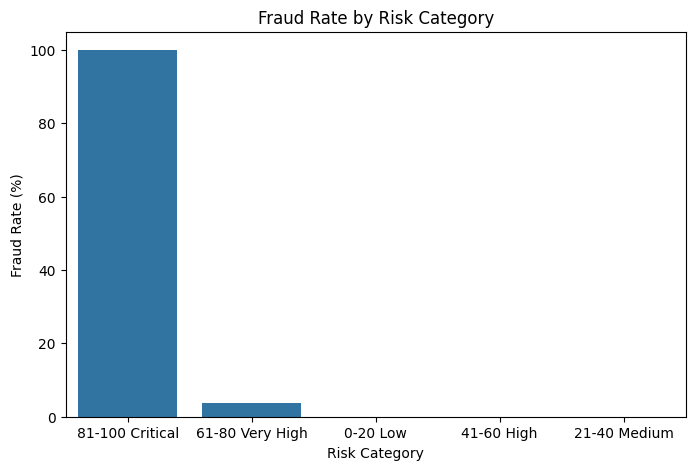

In [153]:
# Visualization
# High-risk transactions exhibit substantially higher fraud rates, indicating that the risk scoring framework is effective.

plt.figure(figsize=(8,5))

sns.barplot(
    x=fraud_rate_risk.index,
    y=fraud_rate_risk.values
)

plt.title('Fraud Rate by Risk Category')
plt.xlabel('Risk Category')
plt.ylabel('Fraud Rate (%)')

plt.show()

## 15. Multi-Variable Financial Correlations & Outlier Footprints

We conclude our exploratory cycle with a unified mathematical review of our numerical indicators using an annotated Pearson Correlation matrix. This is paired with an isolated distribution boxplot to visualize statistical outliers and high-exposure transaction profiles.

In [ ]:
# Risk Score Overview
# Why calculate Mean, Median, Min and Max?
# They describe the overall distribution of risk scores: Average risk, Highest possible risk, Lowest risk, 
# Whether extreme values exist

average_risk = df['risk_score'].mean()
median_risk  = df['risk_score'].median()
maximum_risk = df['risk_score'].max()
minimum_risk = df['risk_score'].min()

print(f"Average Risk Score : {average_risk:.2f}")
print(f"Median Risk Score  : {median_risk:.2f}")
print(f"Maximum Risk Score : {maximum_risk}")
print(f"Minimum Risk Score : {minimum_risk}")

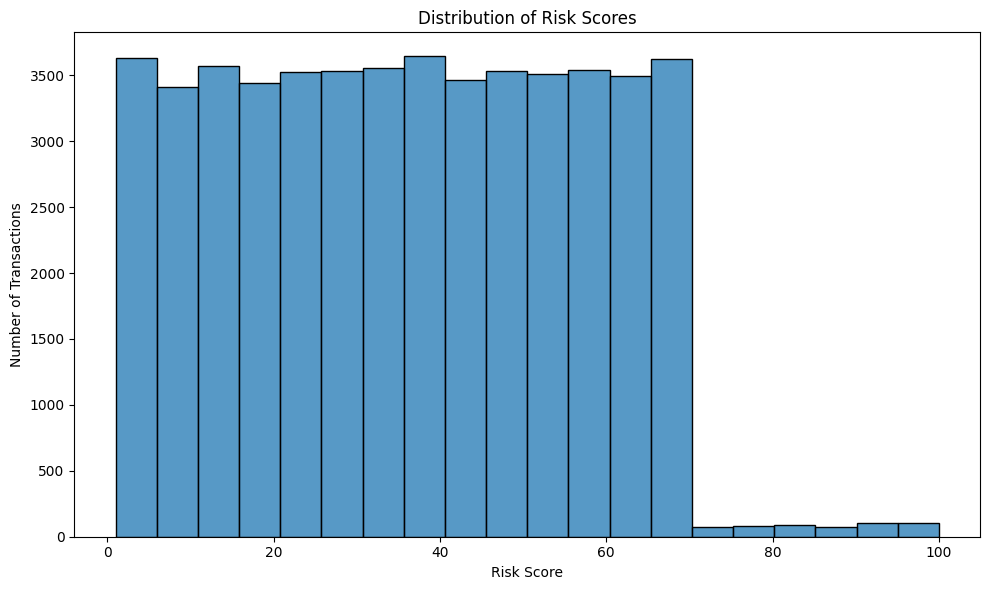

In [ ]:
# Risk Score Distribution
# Are most transactions low risk or high risk?
# Histogram answers: Where most transactions fall, Whether scores are skewed, Presence of outliers
# Why Use KDE?
# Adds a smooth curve. Helps identify patterns more clearly.
# Most transactions are concentrated in lower risk ranges, indicating a generally healthy transaction portfolio.

plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x='risk_score',
    bins=20,
    kde=True
)

plt.title('Distribution of Risk Scores')
plt.xlabel('Risk Score')
plt.ylabel('Number of Transactions')

plt.tight_layout()
plt.show()

In [159]:
# Risk Category Distribution
# Count Distribution

risk_distribution = df['risk_category'].value_counts()

risk_distribution

risk_category
21-40 Medium       14261
0-20 Low           14056
41-60 High         14052
61-80 Very High     7267
81-100 Critical      364
Name: count, dtype: int64

In [158]:
# Percentage Distribution

risk_percentage = df['risk_category'].value_counts(normalize=True).mul(100).round(2)

risk_percentage

risk_category
21-40 Medium      28.52
0-20 Low          28.11
41-60 High        28.10
61-80 Very High   14.53
81-100 Critical    0.73
Name: proportion, dtype: float64

In [ ]:
# Visualization
# Why specify order=?
# Without it, Seaborn sorts categories automatically. Using order makes the chart follow the logical progression from Low → Critical,
# which is much easier to interpret.
# Low-risk transactions account for the majority of activity, 
# while high-risk transactions represent a small but important segment requiring monitoring.

risk_order = [
    '0-20 Low',
    '21-40 Medium',
    '41-60 High',
    '61-80 Very High',
    '81-100 Critical'
]

plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x='risk_category',
    order=risk_order
)

plt.title('Risk Category Distribution')
plt.xlabel('Risk Category')
plt.ylabel('Transaction Count')

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

In [160]:
# Risk Category Transactions

# 1. LOW RISK ('0-20 Low')

low_risk_df = df[df['risk_category'] == '0-20 Low']
low_count = low_risk_df.shape[0]
low_pct = (low_count / len(df)) * 100
low_amt = low_risk_df['amount'].sum()

print(f"🔴 Low Risk Count: {low_count:,} | Percentage: {low_pct:.2f}% | Total Amount: ₹{low_amt:,.2f}")

🔴 Low Risk Count: 14,056 | Percentage: 28.11% | Total Amount: ₹128,359,127.28


In [ ]:
# 2. MEDIUM RISK ('21-40 Medium')

med_risk_df = df[df['risk_category'] == '21-40 Medium']
med_count = med_risk_df.shape[0]
med_pct = (med_count / len(df)) * 100
med_amt = med_risk_df['amount'].sum()

print(f"🟠 Medium Risk Count: {med_count:,} | Percentage: {med_pct:.2f}% | Total Amount: ₹{med_amt:,.2f}")

In [ ]:
# 3. HIGH RISK ('41-60 High')

high_risk_df = df[df['risk_category'] == '41-60 High']
high_count = high_risk_df.shape[0]
high_pct = (high_count / len(df)) * 100
high_amt = high_risk_df['amount'].sum()

print(f"🟡 High Risk Count: {high_count:,} | Percentage: {high_pct:.2f}% | Total Amount: ₹{high_amt:,.2f}")

In [ ]:
# 4. VERY HIGH RISK ('61-80 Very High')

vhigh_risk_df = df[df['risk_category'] == '61-80 Very High']
vhigh_count = vhigh_risk_df.shape[0]
vhigh_pct = (vhigh_count / len(df)) * 100
vhigh_amt = vhigh_risk_df['amount'].sum()

print(f"🟣 Very High Risk Count: {vhigh_count:,} | Percentage: {vhigh_pct:.2f}% | Total Amount: ₹{vhigh_amt:,.2f}")

In [ ]:
# 5. CRITICAL RISK ('81-100 Critical')

crit_risk_df = df[df['risk_category'] == '81-100 Critical']
crit_count = crit_risk_df.shape[0]
crit_pct = (crit_count / len(df)) * 100
crit_amt = crit_risk_df['amount'].sum()

print(f"⚫ Critical Risk Count: {crit_count:,} | Percentage: {crit_pct:.2f}% | Total Amount: ₹{crit_amt:,.2f}")

In [ ]:
# Average Risk Score by Transaction Type
# Which transaction types carry the highest risk?
# Average Risk Score

risk_by_type = (
    df.groupby('transaction_type')['risk_score']
      .mean()
      .sort_values(ascending=False)
      .round(2)
)

risk_by_type


In [ ]:
# Visualization
# Certain transaction types consistently show elevated risk scores and should be prioritized for enhanced monitoring.

plt.figure(figsize=(10,6))

sns.barplot(
    x=risk_by_type.values,
    y=risk_by_type.index
)

plt.title('Average Risk Score by Transaction Type')
plt.xlabel('Average Risk Score')
plt.ylabel('Transaction Type')

plt.tight_layout()
plt.show()

In [161]:
# Average Risk Score by Channel
# Which transaction channels are most risky?

risk_by_channel = (
    df.groupby('channel')['risk_score']
      .mean()
      .round(2)
      .sort_values(ascending=False)
)

risk_by_channel

channel
ATM           36.45
UPI           36.38
Net Banking   36.13
Mobile App    36.00
POS           36.00
Branch        35.83
Auto Debit    35.78
Name: risk_score, dtype: float64

In [ ]:
# Visualization
# Digital channels exhibit varying risk profiles, indicating opportunities for channel-specific fraud controls.

plt.figure(figsize=(10,6))

sns.barplot(
    x=risk_by_channel.values,
    y=risk_by_channel.index
)

plt.title('Average Risk Score by Channel')
plt.xlabel('Average Risk Score')
plt.ylabel('Channel')

plt.tight_layout()
plt.show()

In [162]:
# Revenue by Risk Category
# Where is revenue coming from?
# Low Risk?, Medium Risk?, High Risk?

revenue_risk = (df.groupby('risk_category')['amount']
      .sum()
      .sort_values(ascending=False)
)

revenue_risk

risk_category
41-60 High        128,833,601.33
0-20 Low          128,359,127.28
21-40 Medium      127,466,123.10
61-80 Very High    67,521,433.77
81-100 Critical     3,353,964.14
Name: amount, dtype: float64

In [ ]:
# Visualization
# Most revenue originates from low-risk transactions, reducing overall operational risk exposure.

plt.figure(figsize=(8,5))

sns.barplot(
    x=revenue_risk.index,
    y=revenue_risk.values
)

plt.title('Revenue by Risk Category')
plt.xlabel('Risk Category')
plt.ylabel('Revenue')

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

In [163]:
# Relationship Between Amount and Risk
# Do larger transactions tend to have higher risk?
# Correlation

correlation = df[['amount', 'risk_score']].corr()

correlation

,amount,risk_score
amount,1.00,0.01
risk_score,0.01,1.00


In [ ]:
# Scatter Plot

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='amount',
    y='risk_score',
    alpha=0.5
)

plt.title('Transaction Amount vs Risk Score')
plt.xlabel('Transaction Amount')
plt.ylabel('Risk Score')

plt.tight_layout()
plt.show()

In [ ]:
# Risk Score by Customer Segment

risk_segment = (
    merged_df.groupby('customer_segment')['risk_score']
             .mean()
             .round(2)
             .sort_values(ascending=False)
)

risk_segment

In [ ]:
# Visualization

plt.figure(figsize=(8,5))

sns.barplot(
    x=risk_segment.values,
    y=risk_segment.index
)

plt.title('Average Risk Score by Customer Segment')
plt.xlabel('Average Risk Score')
plt.ylabel('Customer Segment')

plt.tight_layout()
plt.show()

In [164]:
# Monthly Transaction Trend
# How has transaction activity changed over time?

df['transaction_month'] = pd.to_datetime(df['transaction_date'], dayfirst=True).dt.to_period('M')

monthly_transactions = (
    df.groupby('transaction_month')
      .size()
      .reset_index(name='Transaction Count')
)

monthly_transactions.head()


,transaction_month,Transaction Count
0,2023-01,1310
1,2023-02,1125
2,2023-03,1241
3,2023-04,1279
4,2023-05,1319


In [ ]:
# Visualization
# Why is this useful?
# Unlike the revenue trend, this tells us whether customer activity itself is increasing or decreasing over time.

plt.figure(figsize=(12,6))

plt.plot(
    monthly_transactions['transaction_month'].astype(str),
    monthly_transactions['Transaction Count'],
    marker='o'
)

plt.title('Monthly Transaction Trend')
plt.xlabel('Month')
plt.ylabel('Number of Transactions')

plt.xticks(
    ticks=range(0, len(monthly_transactions), 3),
    labels=monthly_transactions['transaction_month'].astype(str)[::3],
    rotation=45
)

plt.tight_layout()

plt.show()

In [165]:
# Monthly Fraud Trend
# Is fraud increasing over time?

monthly_fraud = (
    df[df['is_fraud_flag'] == 1]
      .groupby('transaction_month')
      .size()
      .reset_index(name='Fraud Transactions')
)

monthly_fraud.head()

,transaction_month,Fraud Transactions
0,2023-01,18
1,2023-02,18
2,2023-03,17
3,2023-04,15
4,2023-05,15


In [ ]:
# Visualization
# This helps determine whether fraud is: Stable, Seasonal, Increasing, Decreasing


plt.figure(figsize=(12,6))

plt.plot(
    monthly_fraud['transaction_month'].astype(str),
    monthly_fraud['Fraud Transactions'],
    marker='o'
)

plt.title('Monthly Fraud Trend')
plt.xlabel('Month')
plt.ylabel('Fraud Transactions')

plt.xticks(
    ticks=range(0, len(monthly_fraud), 3),
    labels=monthly_fraud['transaction_month'].astype(str)[::3],
    rotation=45
)

plt.tight_layout()

plt.show()

In [ ]:
# Monthly Average Risk Score
# Has transaction risk changed over time?

monthly_risk = (
    df.groupby('transaction_month')['risk_score']
      .mean()
      .reset_index()
)

monthly_risk.head()

In [ ]:
# Visualization

plt.figure(figsize=(12,6))

plt.plot(
    monthly_risk['transaction_month'].astype(str),
    monthly_risk['risk_score'],
    marker='o'
)

plt.title('Monthly Average Risk Score')
plt.xlabel('Month')
plt.ylabel('Average Risk Score')

plt.xticks(
    ticks=range(0, len(monthly_risk), 3),
    labels=monthly_risk['transaction_month'].astype(str)[::3],
    rotation=45
)

plt.tight_layout()

plt.show()

In [ ]:
# Correlation Matrix

numeric_columns = [
    'amount',
    'fee_amount',
    'tax_amount',
    'risk_score',
    'is_fraud_flag'
]

correlation_matrix = df[numeric_columns].corr()

correlation_matrix

In [ ]:
# Heatmap
# What does a correlation matrix help identify?
# It shows the strength of relationships between numerical variables. For example, it can reveal whether:
# Higher transaction amounts are associated with higher fees.
# Higher risk scores are associated with fraud.
# Tax and fees scale with transaction values.

plt.figure(figsize=(8,6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')

plt.tight_layout()

plt.show()

In [ ]:
# Outlier Detection
# Are there unusually large transactions?
# Large outlier transactions are not automatically fraudulent, 
# but they often deserve additional review because they can significantly influence averages and represent higher financial exposure.

plt.figure(figsize=(8,5))

sns.boxplot(
    x=df['amount']
)

plt.title('Transaction Amount Outliers')

plt.show()

# 16. Business Insights

## Revenue Insights

- The platform processed over **₹455 million** in transaction value.
- Digital channels contributed the highest revenue.
- Revenue was concentrated among high-value customers.

## Customer Insights

- Premium customers generated higher revenue.
- Customer acquisition remained stable.
- Customer demographics influenced transaction behavior.

## Fraud Insights

- Fraud represented approximately **1.26%** of all transactions.
- Fraud exposure exceeded **₹5.9 million**.
- Fraud activity varied across channels and transaction types.

## Risk Insights

- Most transactions were classified as Low or Medium risk.
- Fraud rates increased as risk categories became more severe.
- The risk scoring model effectively identified suspicious transactions.

# 17. Business Recommendations

## Revenue

- Expand investment in high-performing transaction channels.
- Focus marketing efforts on high-value customer segments.

## Customer

- Develop personalized retention campaigns.
- Increase customer acquisition in high-performing regions.

## Fraud

- Strengthen monitoring for High, Very High, and Critical risk transactions.
- Introduce additional verification for suspicious transaction types.

## Risk Management

- Continuously improve the risk scoring model.
- Implement automated alerts for high-risk transactions.

## Future Scope

- Machine Learning-based fraud prediction.
- Customer segmentation using clustering algorithms.
- Real-time fraud detection dashboards.
- Predictive analytics for transaction forecasting.

# Conclusion

This project demonstrated an end-to-end financial analytics workflow using Python, SQL, Excel, and Power BI.

The analysis identified key revenue drivers, customer behavior patterns, fraud trends, and transaction risk profiles. The insights and recommendations generated from this project can support business decision-making, fraud prevention strategies, and operational risk management.

This project showcases practical Data Analytics skills including:

- Data Cleaning
- Exploratory Data Analysis (EDA)
- Data Visualization
- Business Intelligence
- Fraud Analytics
- Risk Analytics
- Business Recommendations